In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

import joblib

In [2]:
silver = pd.read_csv("silver_daily_ohlcv_2000_2025.csv")

macro = pd.read_csv("silver_macroeconomic_monthly.csv")

sentiment = pd.read_csv("silver_sentiment_weekly.csv")

In [4]:
print(silver.columns.tolist())
print(macro.columns.tolist())
print(sentiment.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP', 'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range', 'Intraday_Range_Pct']
['Date', 'Silver_Price_USD', 'Gold_Price_USD', 'Silver_Gold_Ratio', 'Fed_Funds_Rate', 'US_10Y_Yield', 'Real_Interest_Rate', 'US_CPI_Index', 'US_CPI_YoY_Pct', 'DXY_Index', 'Crude_Oil_WTI', 'VIX_Index', 'US_M2_Supply_Trillions', 'India_Repo_Rate', 'USD_INR', 'Silver_Price_INR_Per_Kg', 'Global_PMI', 'US_Unemployment_Rate', 'ETF_Silver_Holdings_MOz']
['Week_Ending', 'Silver_Price_Close', 'CFTC_Commercial_Long', 'CFTC_Commercial_Short', 'CFTC_Commercial_Net', 'CFTC_NonCommercial_Long', 'CFTC_NonCommercial_Short', 'CFTC_NonCommercial_Net', 'CFTC_Total_Open_Interest', 'News_Sentiment_Score', 'Social_Media_Mentions', 'Google_Trends_Index', 'Put_Call_Ratio', 'Implied_Volatility_30D', 'ETF_SLV_Flow_Millions', 'Retail_Bullion_Premium_Pct']


In [5]:
sentiment.rename(
    columns={
        "Week_Ending": "Date"
    },
    inplace=True
)

In [6]:
silver["Date"] = pd.to_datetime(silver["Date"])

macro["Date"] = pd.to_datetime(macro["Date"])

sentiment["Date"] = pd.to_datetime(sentiment["Date"])

In [7]:
print(silver.columns)

print(macro.columns)

print(sentiment.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP',
       'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range',
       'Intraday_Range_Pct'],
      dtype='object')
Index(['Date', 'Silver_Price_USD', 'Gold_Price_USD', 'Silver_Gold_Ratio',
       'Fed_Funds_Rate', 'US_10Y_Yield', 'Real_Interest_Rate', 'US_CPI_Index',
       'US_CPI_YoY_Pct', 'DXY_Index', 'Crude_Oil_WTI', 'VIX_Index',
       'US_M2_Supply_Trillions', 'India_Repo_Rate', 'USD_INR',
       'Silver_Price_INR_Per_Kg', 'Global_PMI', 'US_Unemployment_Rate',
       'ETF_Silver_Holdings_MOz'],
      dtype='object')
Index(['Date', 'Silver_Price_Close', 'CFTC_Commercial_Long',
       'CFTC_Commercial_Short', 'CFTC_Commercial_Net',
       'CFTC_NonCommercial_Long', 'CFTC_NonCommercial_Short',
       'CFTC_NonCommercial_Net', 'CFTC_Total_Open_Interest',
       'News_Sentiment_Score', 'Social_Media_Mentions', 'Google_Trends_Index',
       'Put_Call_Ratio', 'Implied_Volatility_30D', 'ETF_SLV_Flow_Mi

In [8]:
print("Silver Dataset :", silver.shape)

print("Macro Dataset :", macro.shape)

print("Sentiment Dataset :", sentiment.shape)

Silver Dataset : (6783, 13)
Macro Dataset : (312, 19)
Sentiment Dataset : (1043, 16)


In [9]:
def load_data():

    return silver.copy(), macro.copy(), sentiment.copy()

In [10]:
def clean_data(df):

    df = df.sort_values("Date")

    df = df.drop_duplicates()

    df = df.ffill()

    df = df.bfill()

    return df

In [11]:
def merge_sources(
    silver,
    macro,
    sentiment
):

    macro_daily = (

        macro

        .set_index("Date")

        .resample("D")

        .ffill()

        .reset_index()

    )

    sentiment_daily = (

        sentiment

        .set_index("Date")

        .resample("D")

        .ffill()

        .reset_index()

    )

    merged = silver.merge(

        macro_daily,

        on="Date",

        how="left"

    )

    merged = merged.merge(

        sentiment_daily,

        on="Date",

        how="left"

    )

    merged = merged.ffill()

    merged = merged.bfill()

    return merged

In [12]:
def create_features(df):

    df["Daily_Return"] = df["Close"].pct_change()

    df["Volatility_20"] = (

        df["Daily_Return"]

        .rolling(20)

        .std()

    )

    return df

In [13]:
def scale_data(df):

    numeric = df.select_dtypes(

        include=["float64","int64"]

    )

    scaler = MinMaxScaler()

    scaled = scaler.fit_transform(numeric)

    return scaled, scaler

In [14]:
def split_data(df):

    split = int(

        len(df)*0.8

    )

    train = df.iloc[:split]

    test = df.iloc[split:]

    return train, test

In [15]:
silver, macro, sentiment = load_data()

silver = clean_data(silver)

macro = clean_data(macro)

sentiment = clean_data(sentiment)

merged_data = merge_sources(

    silver,

    macro,

    sentiment

)

merged_data = create_features(

    merged_data

)

print(merged_data.shape)

merged_data.head()

(6783, 48)


,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,...,CFTC_Total_Open_Interest,News_Sentiment_Score,Social_Media_Mentions,Google_Trends_Index,Put_Call_Ratio,Implied_Volatility_30D,ETF_SLV_Flow_Millions,Retail_Bullion_Premium_Pct,Daily_Return,Volatility_20
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,...,192194.0,0.4116,209.0,15.0,0.7738,40.5,-43.76,7.25,NaN,NaN
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,...,192194.0,0.4116,209.0,15.0,0.7738,40.5,-43.76,7.25,-0.017916,NaN
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,...,192194.0,0.4116,209.0,15.0,0.7738,40.5,-43.76,7.25,0.008474,NaN
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,...,192194.0,0.4116,209.0,15.0,0.7738,40.5,-43.76,7.25,0.016086,NaN
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,...,192194.0,0.4116,209.0,15.0,0.7738,40.5,-43.76,7.25,0.010337,NaN


In [16]:
merged_data.to_csv(

    "merged_preprocessed_data.csv",

    index=False

)

print("Merged Dataset Saved Successfully")

Merged Dataset Saved Successfully


In [17]:
print("=" * 60)
print("MISSING VALUES BEFORE CLEANING")
print("=" * 60)

missing_before = merged_data.isnull().sum()

missing_before = missing_before[
    missing_before > 0
]

print(missing_before)

print("\nTotal Missing Values:", missing_before.sum())

MISSING VALUES BEFORE CLEANING
Daily_Return      1
Volatility_20    20
dtype: int64

Total Missing Values: 21


In [18]:
merged_data = merged_data.sort_values("Date")

# Forward Fill
merged_data = merged_data.ffill()

# Interpolate numeric columns
numeric_cols = merged_data.select_dtypes(
    include=["number"]
).columns

merged_data[numeric_cols] = merged_data[
    numeric_cols
].interpolate(
    method="linear"
)

# Final Backfill
merged_data = merged_data.bfill()

In [19]:
print("=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)

missing_after = merged_data.isnull().sum()

missing_after = missing_after[
    missing_after > 0
]

print(missing_after)

print("\nRemaining Missing Values:",
      missing_after.sum())

MISSING VALUES AFTER CLEANING
Series([], dtype: int64)

Remaining Missing Values: 0


In [20]:
print("=" * 60)
print("IMPUTATION STRATEGY")
print("=" * 60)

print("""
1. Monthly macroeconomic variables:
   Forward Filled

2. Weekly sentiment variables:
   Forward Filled

3. Small isolated gaps:
   Linear Interpolation

4. Remaining missing values:
   Back Filled

No rows removed.
""")

IMPUTATION STRATEGY

1. Monthly macroeconomic variables:
   Forward Filled

2. Weekly sentiment variables:
   Forward Filled

3. Small isolated gaps:
   Linear Interpolation

4. Remaining missing values:
   Back Filled

No rows removed.



In [21]:
train = merged_data[
    merged_data["Date"] < "2018-01-01"
]

validation = merged_data[
    (merged_data["Date"] >= "2018-01-01") &
    (merged_data["Date"] < "2021-01-01")
]

test = merged_data[
    merged_data["Date"] >= "2021-01-01"
]

In [22]:
print("=" * 60)

print("TRAIN")

print(train["Date"].min())

print(train["Date"].max())

print(train.shape)

print("=" * 60)

print("VALIDATION")

print(validation["Date"].min())

print(validation["Date"].max())

print(validation.shape)

print("=" * 60)

print("TEST")

print(test["Date"].min())

print(test["Date"].max())

print(test.shape)

TRAIN
2000-01-03 00:00:00
2017-12-29 00:00:00
(4695, 48)
VALIDATION
2018-01-01 00:00:00
2020-12-31 00:00:00
(784, 48)
TEST
2021-01-01 00:00:00
2025-12-31 00:00:00
(1304, 48)


In [23]:
assert train["Date"].max() < validation["Date"].min()

assert validation["Date"].max() < test["Date"].min()

print("No Data Leakage Detected")

No Data Leakage Detected


In [24]:
total = len(merged_data)

print("Train %:",
      round(len(train)/total*100,2))

print("Validation %:",
      round(len(validation)/total*100,2))

print("Test %:",
      round(len(test)/total*100,2))

Train %: 69.22
Validation %: 11.56
Test %: 19.22


In [25]:
print("=" * 60)

print("PREPROCESSING REPORT")

print("=" * 60)

print("Total Samples :", len(merged_data))

print("Training Samples :", len(train))

print("Validation Samples :", len(validation))

print("Testing Samples :", len(test))

print()

print("Missing Values :", merged_data.isnull().sum().sum())

print("Duplicate Rows :", merged_data.duplicated().sum())

print()

print("Start Date :", merged_data["Date"].min())

print("End Date :", merged_data["Date"].max())

print("=" * 60)

PREPROCESSING REPORT
Total Samples : 6783
Training Samples : 4695
Validation Samples : 784
Testing Samples : 1304

Missing Values : 0
Duplicate Rows : 0

Start Date : 2000-01-03 00:00:00
End Date : 2025-12-31 00:00:00


In [26]:
merged_data.to_csv(
    "preprocessed_day2_dataset.csv",
    index=False
)

print("Preprocessed Dataset Saved")

Preprocessed Dataset Saved


In [27]:
numeric_features = merged_data.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

if "Close" in numeric_features:
    numeric_features.remove("Close")

print("Total Features:", len(numeric_features))

Total Features: 46


In [28]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

train_minmax = minmax_scaler.fit_transform(
    train[numeric_features]
)

validation_minmax = minmax_scaler.transform(
    validation[numeric_features]
)

test_minmax = minmax_scaler.transform(
    test[numeric_features]
)

In [29]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

train_robust = robust_scaler.fit_transform(
    train[numeric_features]
)

validation_robust = robust_scaler.transform(
    validation[numeric_features]
)

test_robust = robust_scaler.transform(
    test[numeric_features]
)

In [30]:
print("="*60)

print("MinMax Shape")

print(train_minmax.shape)

print("="*60)

print("Robust Shape")

print(train_robust.shape)

MinMax Shape
(4695, 46)
Robust Shape
(4695, 46)


In [31]:
import numpy as np

def create_sequences(
    features,
    target,
    lookback=60,
    horizon=1
):

    X=[]

    y=[]

    for i in range(
        lookback,
        len(features)-horizon+1
    ):

        X.append(
            features[
                i-lookback:i
            ]
        )

        y.append(
            target[
                i+horizon-1
            ]
        )

    return np.array(X),np.array(y)

In [32]:
X30,y30 = create_sequences(

    train_minmax,

    train["Close"].values,

    lookback=30,

    horizon=1

)

print(X30.shape)

(4665, 30, 46)


In [33]:
X60,y60 = create_sequences(

    train_minmax,

    train["Close"].values,

    lookback=60,

    horizon=1

)

print(X60.shape)

(4635, 60, 46)


In [34]:
X90,y90 = create_sequences(

    train_minmax,

    train["Close"].values,

    lookback=90,

    horizon=1

)

print(X90.shape)

(4605, 90, 46)


In [35]:
X5,y5 = create_sequences(

    train_minmax,

    train["Close"].values,

    lookback=60,

    horizon=5

)

print(X5.shape)

(4631, 60, 46)


In [36]:
X20,y20 = create_sequences(

    train_minmax,

    train["Close"].values,

    lookback=60,

    horizon=20

)

print(X20.shape)

(4616, 60, 46)


In [37]:
lag_features = [

"Open",

"High",

"Low",

"Volume",

"VWAP",

"Returns_Pct",

"Log_Returns"

]

X_train = train.drop(

columns=["Date","Close"]

)

y_train = train["Close"]

X_validation = validation.drop(

columns=["Date","Close"]

)

y_validation = validation["Close"]

X_test = test.drop(

columns=["Date","Close"]

)

y_test = test["Close"]

print(X_train.shape)

print(X_validation.shape)

print(X_test.shape)

(4695, 46)
(784, 46)
(1304, 46)


In [38]:
print("Train Last Date")

print(train["Date"].max())

print()

print("Validation First Date")

print(validation["Date"].min())

print()

print("Test First Date")

print(test["Date"].min())

Train Last Date
2017-12-29 00:00:00

Validation First Date
2018-01-01 00:00:00

Test First Date
2021-01-01 00:00:00


In [39]:
import joblib

joblib.dump(

minmax_scaler,

"MinMaxScaler.pkl"

)

joblib.dump(

robust_scaler,

"RobustScaler.pkl"

)

print("Scalers Saved")

Scalers Saved


In [40]:
joblib.dump(X30,"X30.pkl")
joblib.dump(X60,"X60.pkl")
joblib.dump(X90,"X90.pkl")

joblib.dump(y30,"y30.pkl")
joblib.dump(y60,"y60.pkl")
joblib.dump(y90,"y90.pkl")

print("Sequences Saved")

Sequences Saved


In [41]:
train.to_pickle(

"train.pkl"

)

validation.to_pickle(

"validation.pkl"

)

test.to_pickle(

"test.pkl"

)

print("Train Validation Test Saved")

Train Validation Test Saved


In [42]:
X_train.to_pickle(

"X_train.pkl"

)

X_validation.to_pickle(

"X_validation.pkl"

)

X_test.to_pickle(

"X_test.pkl"

)

y_train.to_pickle(

"y_train.pkl"

)

y_validation.to_pickle(

"y_validation.pkl"

)

y_test.to_pickle(

"y_test.pkl"

)

print("XGBoost Dataset Saved")

XGBoost Dataset Saved


In [43]:
print("="*70)

print("DAY 2 PREPROCESSING COMPLETED")

print("="*70)

print("Modular Pipeline        ✓")

print("Missing Values          ✓")

print("Forward Fill            ✓")

print("Interpolation           ✓")

print("Time Split              ✓")

print("Leakage Prevention      ✓")

print("MinMax Scaling          ✓")

print("Robust Scaling          ✓")

print("LSTM Sequences          ✓")

print("30 Day Lookback         ✓")

print("60 Day Lookback         ✓")

print("90 Day Lookback         ✓")

print("1 Day Forecast          ✓")

print("5 Day Forecast          ✓")

print("20 Day Forecast         ✓")

print("XGBoost Dataset         ✓")

print("Pickle Files            ✓")

print("="*70)

DAY 2 PREPROCESSING COMPLETED
Modular Pipeline        ✓
Missing Values          ✓
Forward Fill            ✓
Interpolation           ✓
Time Split              ✓
Leakage Prevention      ✓
MinMax Scaling          ✓
Robust Scaling          ✓
LSTM Sequences          ✓
30 Day Lookback         ✓
60 Day Lookback         ✓
90 Day Lookback         ✓
1 Day Forecast          ✓
5 Day Forecast          ✓
20 Day Forecast         ✓
XGBoost Dataset         ✓
Pickle Files            ✓


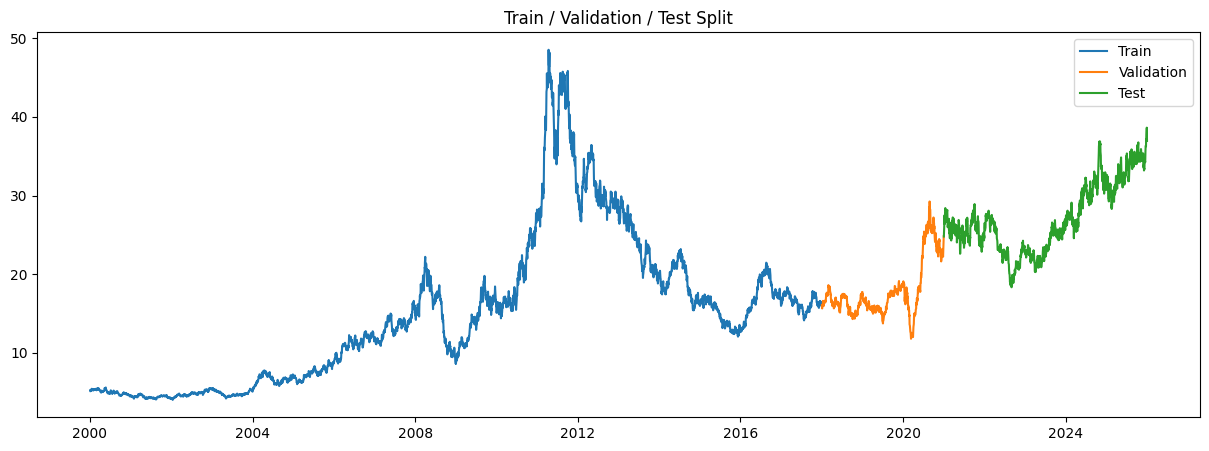

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    train["Date"],
    train["Close"],
    label="Train"
)

plt.plot(
    validation["Date"],
    validation["Close"],
    label="Validation"
)

plt.plot(
    test["Date"],
    test["Close"],
    label="Test"
)

plt.legend()

plt.title("Train / Validation / Test Split")

plt.show()